#Fusing is used to reduce memory read/writes

In [1]:
!pip install torch
!pip install triton

In [2]:
import torch
import triton
import triton.language as tl
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [26]:
#step 1
def naive_softmax(x):
  #assume input size (M, N)

  #reads M*N elements and writes M elements
  x_max = x.max(dim=1)[0]

  #read MN + M elemets, subtraction is MN flops, write MN elemets
  z = x - x_max[:, None] # shape (M, N) - shape (M. 1) = shape (M, N)

  #reading MN elements and writing MN elements
  numerator = tl.exp(z)

  #read MN elements, then MN flops for sum, write M elements
  denominator = numerator.sum(dim=1)

  #reads MN + M elements, division MN flops, write MN elements
  out = numerator / denominator[:, None] #shape (M, N) / shape (M, 1) = shape (M, N)

  #so in total we did 8MN + 4M memory operations
  return out

#step 5
@triton.jit
def _softmax_kernel(
    input_ptr, output_ptr,
    input_row_stride, output_row_stride,
    n_rows, n_cols,
    BLOCK_SIZE: tl.constexpr, # dont need to pass to kernel thru parameters if did warmup
    num_stages: tl.constexpr,
):
  # shape (M, N)
  #BLOCK_SIZE = next_power_of_2(N)

  PID = tl.program_id(axis = 0)

  row_step = tl.num_programs(0)
  #if 4 programs, then row_step = 4
  #if n_rows = 6
  #pid 0 would get row 0
  #pid 1 would get row 1
  #pid 2 would get row 2
  #pid 3 would get row 3
  #once they're done with their first assigned rows
  #pid 0 += row_step so now it gets row 4
  #pid 1 += row_step so now it gets row 5

  for row_idx in tl.range(PID, n_rows, row_step, num_stages=num_stages): # if pid = 0; the it would give me 0 and then 4
    row_start_ptr = input_ptr + row_idx * input_row_stride
    col_offsets = tl.arange(0, BLOCK_SIZE)
    input_ptrs = row_start_ptr + col_offsets
    mask = col_offsets < n_cols

    #only reading step -> MN elements
    #doing this multiple operations in one kernel is called kernel fusion
    row = tl.load(input_ptrs, mask=mask, other = float('-inf')) # specific choice of other which fits best with softmax; shape (BLOCK_SIZE) which is roughly shape (n_cols)

    # row_minus_max = row - tl.max(row, axis=0) # shape (BLOCK_SIZE) - (1)  -> (BLOCK_SIZE)
    # numerator = tl.exp(row - row_minus_max) # shape (BLOCK_SIZE)
    # denominator = tl.sum(numerator, axis = 0) # shape (1)
    # softmax_output = numerator / denominator # shape (BLOCK_SIZE)

    row_max = tl.max(row, axis=0)
    row_minus_max = row - row_max
    numerator = tl.exp(row_minus_max)
    denominator = tl.sum(numerator, axis=0)
    softmax_output = numerator / denominator

    output_row_start_ptr = output_ptr + row_idx * output_row_stride
    output_ptrs = output_row_start_ptr + col_offsets
    tl.store(output_ptrs, softmax_output, mask = mask)


#step 3 (Main thing to note and understand)
properties = triton.runtime.driver.active.utils.get_device_properties(torch.cuda.current_device())
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"]
TOTAL_SRAM_PER_SM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]

#step 4 (Main thing to note and understand; specifically how program size is selected)
def softmax(x):
  n_rows, n_cols = x.shape
  BLOCK_SIZE = triton.next_power_of_2(n_cols)

  num_warps = 4
  if BLOCK_SIZE >= 2048:
    num_warps = 8
  if BLOCK_SIZE >= 4096:
    num_warps = 16

  num_stages = 4 if TOTAL_SRAM_PER_SM > 200_000 else 2

  y = torch.empty_like(x)

  kernel = _softmax_kernel.warmup(
      x, y,
      x.stride(0), y.stride(0),
      n_rows, n_cols,
      BLOCK_SIZE=BLOCK_SIZE,
      num_stages=num_stages,
      num_warps=num_warps,
      grid=(1,),
  )
  kernel._init_handles()
  n_regs_per_program = kernel.n_regs
  sram_needed_per_program = kernel.metadata.shared

  reg_occupancy = NUM_REGS // (n_regs_per_program * WARP_SIZE * num_warps)
  sram_occupancy = TOTAL_SRAM_PER_SM // sram_needed_per_program

  programs_per_sm = min(reg_occupancy, sram_occupancy)
  num_programs = min(NUM_SM * programs_per_sm, n_rows)

  grid = (num_programs, 1, 1)

  kernel[grid](
    x, y,
    x.stride(0), y.stride(0),
    n_rows, n_cols,
    BLOCK_SIZE,
    num_stages,
)

  return y

  # x is shape (M, N)
  # x.stride() would be (N, 1)
  # x.stride(0) would be N
  # x.stride(1) would be 1
  # example: z shape (B, N, D)
  # z.stride() should be (N*D, D, 1)



#step 2
def test_softmax_kernel(size: tuple, atol=1e-3, rtol=1e-3, device=DEVICE):
  torch.manual_seed(0)
  x = torch.randn(size[0], size[1], device = DEVICE)
  z_tri = softmax(x)
  z_ref = torch.softmax(x, axis=1)
  torch.testing.assert_allclose(z_tri, z_ref, atol=atol, rtol=rtol)
  print('test passed')


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals = [128*i for i in range(2, 100)],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Pytorch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='softmax-performance',
        args={'M':4096},
    )
)
def benchmark_softmax(M, N, provider):
  x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

  #standalone the gpu for the given task and ensures no distractions
  stream = getattr(torch, DEVICE.type).Stream()
  getattr(torch, DEVICE.type).set_stream(stream)

  if provider == 'torch':
    ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=1))

  if provider == 'triton':
    ms = triton.testing.do_bench(lambda: softmax(x))

  gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
  return gbps(ms)

In [27]:
!pip install numpy pandas pytest matplotlib

/tmp/ipykernel_1002/2743287334.py:142: FutureWarning: `torch.testing.assert_allclose()` is deprecated since 1.12 and will be removed in a future release. Please use `torch.testing.assert_close()` instead. You can find detailed upgrade instructions in https://github.com/pytorch/pytorch/issues/61844.
  torch.testing.assert_allclose(z_tri, z_ref, atol=atol, rtol=rtol)


test passed


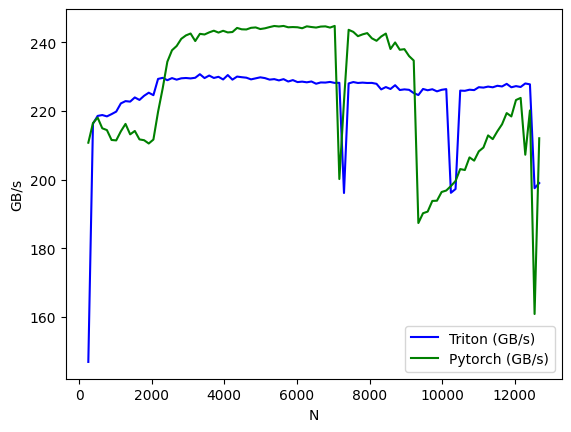

In [28]:
test_softmax_kernel((1823, 781))
import sys
benchmark_softmax.run(save_path = '.', print_data=False)